In [218]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [219]:
import os
import pickle
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from pathlib import Path

from openquake.hazardlib.imt import PGA, SA, RSD595, AvgSA, IMT

from pickagm.distributions import ensemble_ecdfs

from phd_project.config.config import load_config 
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    ESHM20SiteRupCtxBuilder,
    create_gmm_map,
    create_corr_model_map,
    calculate_site_gcim_distributions_for_all_sites,
    get_record_ensembles_for_site_and_poe,
    get_record_ensembles_for_sites,
    get_record_ensembles_for_single_site,
    get_gcim_distributions_for_single_site_and_poe,
    get_record_ensembles_for_single_distribution,
    get_imtl_from_disaggstats,
    get_imtl_from_disaggstats,
    get_gcim_distributions_for_single_site
)
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
from phd_project.plotting.plotting import custom_log_formatter

cfg = load_config()

In [220]:
# Load the disaggregation data
fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data_AvgSA_03 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats_AvgSA_03 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data_AvgSA_06 = pickle.load(f)

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats_AvgSA_06 = pickle.load(f)

# load the site file
sites = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])

# load the flatfiles
flatfile_folder = cfg["proc_data"]["corr_model"] / "reverse" / "flatfiles"
flatfiles = {}
for f in [f for f in os.listdir(flatfile_folder) if f.endswith(".csv")]:
    tag = f.split("_")[0]
    flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0, low_memory=False)

flatfiles["volcanic"] = pd.read_csv(cfg["raw_data"]["gm_flatfiles"] / "volcanic_lanzanoluzi_flatfile.csv", 
                                    delimiter=";", index_col=0)

# load the preprocessed gm database
gm_database = pd.read_csv(cfg["proc_data"]["gm_database"], sep=",", low_memory=False, header=[0, 1])

In [221]:
# create the average depth map for each TRT #TODO:: if this needs to be more specific
average_depths = {
    "Craton": flatfiles["asc"]["ev_depth_km"].mean(),
    "Non-Subduction Deep": flatfiles["vran"]["ev_depth_km"].mean(),
    "Shallow Default": flatfiles["asc"]["ev_depth_km"].mean(),
    "Subduction Inslab": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Subduction Interface": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Volcanic": flatfiles["volcanic"]["ev_depth_km"].mean(),
}

# the map of what sim trts are allowed to match with what record trts
OK_TRT_MATCHES = {
    "Craton": ["Shallow Default"],
    "Non-Subduction Deep": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Shallow Default": ["Shallow Default"],
    "Subduction Inslab": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Subduction Interface": ["Subduction Interface"],
    "Volcanic": ["Shallow Default"],
}

occurence = True    # the record selection should be performed based on occurence

# AvgSA([0, 3])

In [222]:
# set some parameters for the selection
t_lower = 0.025     # lower SA period considered in selection
t_upper = 3         # upper SA period considered in selection
n_periods = 20      # number of periods to consider in selection

conditioning_imt: IMT = AvgSA([0,3])                      
nonSA_imts: list[IMT] = [AvgSA([0,3]), RSD595(), PGA()] 
sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
SA_imts: list[IMT] = [SA(period) for period in sa_periods]
selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts
nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# weights of the IMs
weight_rsd595 = 0.30
n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
                        else weight_rsd595 for imt in selection_imts])
imt_weights /= imt_weights.sum()

# some other things
disagg_type = "TRT_Mag_Dist_Eps"
percentiles = [0.05, 0.16, 0.5, 0.84, 0.95]     # percentiles of the gcim distribution to return  
assumed_rake = 0                                # assumed rake for RSD595 calculation

In [223]:
# filter the gm_database so that only the selection and conditioning ims are present
gm_db_AvgSA_03 = gm_database.copy()
updated_ims = mf.filter_gm_database_on_imts(
    gm_db_AvgSA_03["ims"], selection_imts + [conditioning_imt])
updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
gm_db_AvgSA_03 = pd.concat([gm_db_AvgSA_03.drop('ims', axis=1, level=0), updated_ims], axis=1)

# Create the GMM Map for AvgSA by reading the logic tree
AvgSA_03_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to3_median_branch.xml"
AvgSA_03_gmm_map = create_gmm_map(AvgSA_03_lt_fp)

# get the correlation model map
AvgSA_03_corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

In [235]:
# set up the selection context:
selection_ctx_AvgSA_03 = {
    "n_ensembles": 20,
    "n_samples": 30,
    "conditioning_imt": conditioning_imt ,
    "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
    "selection_imts": selection_imts ,
    "imt_weights": imt_weights ,
    "sites": sites ,
    "ctx_builder": ESHM20SiteRupCtxBuilder ,
    "ctx_builder_params": ["average_depths", "assumed_rake"] ,
    "average_depths": average_depths ,
    "assumed_rake": assumed_rake ,
    "gmm_map": AvgSA_03_gmm_map ,
    "corr_map": AvgSA_03_corr_map ,
    "m_bound_model": "tarbali_and_bradley_2016" ,
    "d_bound_model": "tarbali_and_bradley_2016" ,
    "vs30_bound_model": "tarbali_and_bradley_2016" ,
    "sf_bounds": None, #(0.25, 4) ,
    "usable_T": t_upper ,
    "max_n_recs": 3 ,
    "p_value": 0.05 ,
    "ok_trt_matches": OK_TRT_MATCHES ,
    "occurence": True ,
}

In [225]:
# seismicity = "high"
# region = 1
# site = 30
# rng_seed = 2

# site_gcim_dists = get_gcim_distributions_for_single_site(
#     site, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, selection_ctx_AvgSA_03)

# record_selection_results_AvgSA03 = get_record_ensembles_for_single_site(
#     site, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, site_gcim_dists, gm_db_AvgSA_03, selection_ctx_AvgSA_03, 2)

In [226]:
# fp = Path(r"C:\Users\clemettn\Documents\phd\data_processed\06_gm_selection")
# with open(fp / f"site{site}_gcim_data_rake{assumed_rake}_sf_limit.pickle", "wb") as file:
#     pickle.dump(site_gcim_dists, file)

# with open(fp / f"site{site}_record_selections_rake{assumed_rake}_sf_limit.pickle", "wb") as file:
#     pickle.dump(record_selection_results_AvgSA03, file)

In [227]:
# records = record_selection_results_AvgSA03[0.0001]
# es = records["all_ensembles"]
# e = es[0]
# print(e.keys())
# for ei in es:
#     print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

In [228]:
# ensemble_data = records["best_ensemble"]
# ecdfs = ensemble_ecdfs(ensemble_data["recs"]["ims_scaled"])
# ensemble_data["ecdfs"] = ecdfs
# print(ensemble_data.keys())
# print(ecdfs.keys())

In [229]:
# im = "RSD595"
# poe1 = 0.000404
# poe2 = 0.0001
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), sharex=True, sharey=True)

# # Figure 1 -> RSD595 KS-Test poe1
# records1 = record_selection_results_AvgSA03[poe1]
# if records1["ensemble_found"]:
#     ensemble1 = records1["best_ensemble"]
#     ecdfs1 = ensemble_ecdfs(ensemble1["recs"]["ims_scaled"])
# else:
#     rscores = np.array([r["R-score"] for r in records1["all_ensembles"]])
#     idx = np.where(rscores == min(rscores))[0][0]
#     ensemble1 = records1["all_ensembles"][idx]
#     print(f"KS-Test failed for poe {poe1}. Showing ensemble with R = {ensemble1["R-score"]:.4f} and failed IMs {ensemble1["ks_failed_ims"]}")
#     ecdfs1 = ensemble_ecdfs(ensemble1["recs"]["ims_scaled"])

# # target cdf and ks bounds
# ks_bounds = records1["ks_bounds"][im]
# xs = ks_bounds[:, 0]
# lower = ks_bounds[:, 1]
# cdf = ks_bounds[:, 2]
# upper = ks_bounds[:, 3]

# # ecdf of records
# im_ecdf = ecdfs1[im]

# ax1.plot(xs, lower, color="0.8", ls="--")
# ax1.plot(xs, cdf, color="0.8", ls="-")
# ax1.plot(xs, upper, color="0.8", ls="--")
# ax1.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# # ax1.grid(True, which="both", ls="-.", color="0.8")
# # ax1.minorticks_on()

# # Figure 2 -> RSD595 KS-Test poe2
# records2 = record_selection_results_AvgSA03[poe2]
# if records2["ensemble_found"]:
#     ensemble2 = records2["best_ensemble"]
#     ecdfs2 = ensemble_ecdfs(ensemble2["recs"]["ims_scaled"])
# else:
#     rscores = np.array([r["R-score"] for r in records2["all_ensembles"]])
#     idx = np.where(rscores == min(rscores))[0][0]
#     ensemble2 = records2["all_ensembles"][idx]
#     print(f"KS-Test failed for poe {poe2}. Showing ensemble with R = {ensemble2["R-score"]:.4f} and failed IMs {ensemble2["ks_failed_ims"]}")
#     ecdfs2 = ensemble_ecdfs(ensemble2["recs"]["ims_scaled"])

# # target cdf and ks bounds
# ks_bounds = records["ks_bounds"][im]
# xs = ks_bounds[:, 0]
# lower = ks_bounds[:, 1]
# cdf = ks_bounds[:, 2]
# upper = ks_bounds[:, 3]

# # ecdf of records
# im_ecdf = ecdfs2[im]

# ax2.plot(xs, lower, color="0.8", ls="--")
# ax2.plot(xs, cdf, color="0.8", ls="-")
# ax2.plot(xs, upper, color="0.8", ls="--")
# ax2.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# ax2.set_xlim(0, 80)
# ax2.set_ylim(0, 1.0)
# # ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
# ax2.set_ylabel(r"P[IM <= im]")
# # ax2.grid(True, which="both", ls="-.", color="0.8")
# # ax2.minorticks_on()
# fig.tight_layout()


In [230]:

# disagg_dist = disagg_data_AvgSA_03[(seismicity, region)][site]["AvgSA"][poe]

# iml = get_imtl_from_disaggstats(disagg_stats_AvgSA_03, site, seismicity, region, "AvgSA", poe)

# site_params = selection_ctx_AvgSA_03["sites"].loc[site,:].to_dict()

# gcim_out = get_gcim_distributions_for_single_site_and_poe(
#     site, poe, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, selection_ctx_AvgSA_03)

# records = get_record_ensembles_for_single_distribution(
#     disagg_dist, iml, selection_ctx_AvgSA_03, gm_db_AvgSA_03, 
#     site_params, gcim_out["cdfs"], rng_seed)

# records = get_record_ensembles_for_site_and_poe(
#     30, 0.002103, disagg_data_AvgSA_03, disagg_stats_AvgSA_03, gcim_AvgSA_03, 
#     gm_db_AvgSA_03, selection_ctx_AvgSA_03, 2)

print(f"Success: {records["ensemble_found"]}")

Success: False


In [231]:
# es = records["all_ensembles"]
# e = es[0]
# print(e.keys())
# for ei in es:
#     print(f"{ei["ks_passed"]}, {ei["R-score"]:.4f}, {ei["ks_failed_ims"]}")

## GCIM Target Distributions

In [236]:
LOAD_GCIM_IF_EXISTS = True
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_03_rake{int(assumed_rake)}.pickle"

if LOAD_GCIM_IF_EXISTS: # load the gcim distributions instead of 
    no_file = False
    if gcim_dist_fp.is_file():
        with open(gcim_dist_fp, "rb") as file:
            gcim_AvgSA_03 = pickle.load(file)
        print("Existing GCIM distribution data loaded...")
    else:
        no_file = True
        print("No existing GCIM distribution data found...")

if (not LOAD_GCIM_IF_EXISTS) or no_file:
    # calculate the gcims and save them
    gcim_AvgSA_03 = calculate_site_gcim_distributions_for_all_sites(
        disagg_data_AvgSA_03, disagg_stats_AvgSA_03, conditioning_imt, 
        selection_imts, sites, AvgSA_03_gmm_map, AvgSA_03_corr_map, 
        average_depths, assumed_rake, occurence, percentiles)

    with open(gcim_dist_fp, "wb") as file:
        pickle.dump(gcim_AvgSA_03, file)

Existing GCIM distribution data loaded...


## Selection

In [237]:
LOAD_RS_IF_EXISTS = False
only_sites = [30, 31, 37, 41, 3, 9]
AvgSA_03_gm_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_intermdiate_selection_results_rake{int(assumed_rake)}.pickle"

if LOAD_RS_IF_EXISTS: # load the gcim distributions instead of 
    no_file = False
    if AvgSA_03_gm_fp.is_file():
        with open(AvgSA_03_gm_fp, "rb") as file:
            record_selection_results_AvgSA03 = pickle.load(file)
        print("Existing record selection data loaded...")
    else:
        no_file = True
        print("No existing record selection data found...")
        
if (not LOAD_RS_IF_EXISTS) or no_file:
    # do the record selection for all sites and save the results
    record_selection_results_AvgSA03 = get_record_ensembles_for_sites(
        disagg_data_AvgSA_03, disagg_stats_AvgSA_03, gcim_AvgSA_03, 
        gm_db_AvgSA_03, selection_ctx_AvgSA_03, 2, only_sites    
        )

    # Save the results
    with open(AvgSA_03_gm_fp, "wb") as file:
        pickle.dump(record_selection_results_AvgSA03, file)

Selecting Record Ensembles...
  Region 0 - high seismicity
    site id: 30
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
    site id: 31
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 1 - high seismicity
    site id: 37
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 2 - high seismicity
    site id: 41
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 3 - high seismicity
  Region 4 - high seismicity
  Region 5 - high seismicity
  Region 0 - lowmod seismicity
    site id: 3
        poe: 0.004988
        poe: 0.002103
        poe: 0.001
        poe: 0.000404
        poe: 0.000201
        poe: 0.0001
  Region 1 - lowmod seismicity
    site id: 9
     

In [238]:
# Check if all the sites and poes found a set of records successfully
no_ensemble_found_AvgSA03 = []
for (s, r) in record_selection_results_AvgSA03.keys():
    for site_id in record_selection_results_AvgSA03[(s,r)].keys():
        for poe, rsr in record_selection_results_AvgSA03[(s,r)][site_id].items():
            if not rsr["ensemble_found"]:
                no_ensemble_found_AvgSA03.append(((s,r), site_id, poe))

print(f"No records found for {len(no_ensemble_found_AvgSA03)} combinations of site and poe")
for ii in no_ensemble_found_AvgSA03:
    print(ii)

No records found for 0 combinations of site and poe


In [11]:
# get the best ensembles (the final record selection for each site)
# calculate the ecdfs, trt stats, and plot images.
# save everything in the results/folder

# get a list of all the esm and ngasub records that need to be downloaded


# Plotting

In [18]:
# ('high', 0), 30, np.float64(0.019801))

In [19]:
# ensemble_data = records["best_ensemble"]
# ecdfs = ensemble_ecdfs(ensemble_data["recs"]["ims_scaled"])
# ensemble_data["ecdfs"] = ecdfs
# print(ensemble_data.keys())
# print(ecdfs.keys())

In [20]:
# gcim_data = gcim_AvgSA_03[("high", 0)][31][0.000201]
# gcim_data["stats"]

In [21]:
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker
# import matplotlib.lines as mlines

# from phd_project.plotting.plotting import custom_log_formatter

In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# trt_format = {
#     "Shallow Default": {"color":"b", "alpha": 0.8, "lw":1} ,
#     "Subduction Interface": {"color":"r", "alpha": 0.5, "lw":1} ,
#     "Subduction Inslab": {"color":"g", "alpha": 0.8, "lw":1} ,
# }

# periods = [0.01] + [im.period for im in selection_imts if im.name == "SA"]
# sas = ["PGA"] + [im.string for im in selection_imts if im.name == "SA"]
# sa_dists = gcim_data["stats"].loc[sas, :]
# recs = ensemble_data["recs"]

# # Figure 1 Conditional Spectra
# for ii, (_, row) in enumerate(recs["ims_scaled"].iterrows()):
#     trt = ensemble_data["ctxs"][ii].trt
#     sa_rec = row[sas]
#     if trt != "Shallow Default":
#         alpha = 0.6
#     else:
#         alpha = 1.0
#     ax1.loglog(periods, sa_rec, **trt_format[trt])

# ax1.loglog(periods, sa_dists["p5"], color="k", ls="--")
# ax1.loglog(periods, sa_dists["p16"], color="k", ls="-.")
# ax1.loglog(periods, sa_dists["p50"], color="k")
# ax1.loglog(periods, sa_dists["p84"], color="k", ls="-.")
# ax1.loglog(periods, sa_dists["p95"], color="k", ls="--")

# formatter = ticker.FuncFormatter(custom_log_formatter)
# ax1.xaxis.set_major_formatter(formatter)
# ax1.set_xlim(0.01, 8)
# ax1.set_ylim(1e-2, 5)

# ax1.grid(True, which="both", ls="-.", color="0.8")
# ax1.minorticks_on()
# ax1.tick_params(axis='y', which='minor', left=False)
# ax1.set_xlabel("Period, [s]")
# ax1.set_ylabel("SA [g]")

# # Figure 2 -> RSD595 KS-Test
# im = "RSD595"
# # target cdf and ks bounds
# ks_bounds = records["ks_bounds"][im]
# xs = ks_bounds[:, 0]
# lower = ks_bounds[:, 1]
# cdf = ks_bounds[:, 2]
# upper = ks_bounds[:, 3]

# # ecdf of records
# im_ecdf = ecdfs[im]

# ax2.plot(xs, lower, color="0.8", ls="--")
# ax2.plot(xs, cdf, color="0.8", ls="-")
# ax2.plot(xs, upper, color="0.8", ls="--")
# ax2.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
# ax2.set_xlim(0, 120)
# ax2.set_ylim(0, 1.0)
# ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
# ax2.set_ylabel(r"P[IM <= im]")
# ax1.grid(True, which="both", ls="-.", color="0.8")
# ax1.minorticks_on()
# fig.tight_layout()


In [23]:
# # The trt stats
# trt_stats = pd.DataFrame(recs.groupby(("metadata", "trt")).size())
# trt_stats.columns = ["count"]
# trt_stats["proportions"] = np.round(trt_stats["count"] / trt_stats["count"].sum(), 3)
# trt_stats

In [24]:
# # Table of KS results
# data = {im : {"ks_statistic": ksr.statistic * ksr.statistic_sign, 
#               "pvalue": ksr.pvalue, 
#               "location": ksr.statistic_location} 
#         for im , ksr in ensemble_data["ks_results"].items()}

# ks_data = pd.DataFrame.from_dict(data, orient="index")
# ks_data

In [25]:
# # Record data
# metadata = recs["metadata"]
# record_data_for_table = metadata[["event_id", "database", "station_code", "trt", "mag", "rjb", "vs30", "component"]]
# record_data_for_table

In [ ]:
# fp = Path(r"C:\Users\clemettn\Documents\phd\data_processed\06_gm_selection")
# site = 30
# rakes = [0, 90, -90]

# site_records = {}
# site_records_sflim = {}

# for rake in rakes:
#     with open(fp / f"site{site}_record_selections_rake{rake}.pickle", "rb") as file:
#         site_records[rake] = pickle.load(file)

#     with open(fp / f"site{site}_record_selections_rake{rake}_sf_limit.pickle", "rb") as file:
#         site_records_sflim[rake] = pickle.load(file)

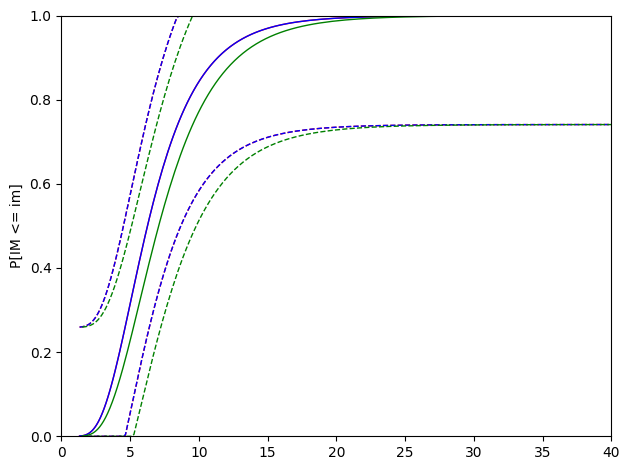

In [ ]:
# im = "RSD595"
# poe = 0.0001
# fig, ax = plt.subplots()

# for rake, c in zip(rakes, ["r", "b", "g"]):
#     rs = site_records[rake][poe]
#     ensemble = rs["best_ensemble"]
#     ecdfs = ensemble_ecdfs(ensemble["recs"]["ims_scaled"])

#     # target cdf and ks bounds
#     ks_bounds = rs["ks_bounds"][im]
#     xs = ks_bounds[:, 0]
#     lower = ks_bounds[:, 1]
#     cdf = ks_bounds[:, 2]
#     upper = ks_bounds[:, 3]

#     # ecdf of records
#     im_ecdf = ecdfs1[im]

#     ax.plot(xs, lower, ls="--", color=c, lw=1.0)
#     ax.plot(xs, cdf, ls="-", color=c, lw=1.0)
#     ax.plot(xs, upper, ls="--", color=c, lw=1.0)
#     # ax.plot(im_ecdf[:,0], im_ecdf[:,1], color="b")
#     # ax1.grid(True, which="both", ls="-.", color="0.8")
#     # ax1.minorticks_on()

#     ax.set_xlim(0, 40)
#     ax.set_ylim(0, 1.0)
#     # ax2.set_xlabel(r"$D_{s,5\%-95\%}$ [s]")
#     ax.set_ylabel(r"P[IM <= im]")
#     # ax2.grid(True, which="both", ls="-.", color="0.8")
#     # ax2.minorticks_on()
#     fig.tight_layout()